# XGBoost (level/QLIKE) vs log-HAR — 6y window, δ=0.999, MCS

Does a properly-built **gradient-boosted tree** model beat (or join) the best **log-HAR** specs, and does
the **4-fold walk-forward CV + per-fold-best ensemble** actually help vs a single fixed-hyperparameter
model? Every model uses a **6-year rolling window (1512 days)** and **geometric recency decay δ=0.999**, and
is scored by **QLIKE in levels** on the **same common out-of-sample dates**.

**XGBoost protocol (shared by all XGBoost variants).** Trees need no log transform (splits are
monotonic-invariant in the features) and the target need not be normal, so XGBoost is built the native way:
- **Level target + custom QLIKE objective.** Forecast `f = exp(p)` (log link → positivity); QLIKE
  `L = y/f − log(y/f) − 1` gives `grad = w·(1 − y/f)`, `hess = w·(y/f)`. No log target, no Duan smearing.
- **Recency** via `w = δ**age` **baked into grad/hess** (the tree analog of WLS).
- **Early stopping** (QLIKE metric on a chronological validation block) auto-tunes the tree count.
- **Bi-weekly refit** (every 10 trading days, held fixed in between); forecasts are still daily, 1-step-ahead.

**The one axis that differs — hyperparameter selection:**
- **CV-ensemble variants** (`xgb_matched`, `xgb_rich`): 4 expanding walk-forward folds, grid over
  `max_depth∈{2,3,4} × lr∈{0.03,0.1}`; each fold picks its own best config; all four refit on the full
  window and **averaged**.
- **No-CV variants** (`xgb_matched_nocv`, `xgb_rich_nocv`): a **single** model with **fixed** params
  (`max_depth=3, lr=0.05`), early-stopped on one [0,80%)→[80,100%) split, refit on the full window. No grid,
  no ensemble.

**HAR** stays daily-refit and vectorized (from `HAR_simpleOLS_3d_with_macro.ipynb`).

**Models (all 6y / δ=0.999):** `xgb_matched`, `xgb_rich` (CV-ensemble); `xgb_matched_nocv`,
`xgb_rich_nocv` (single fixed-param); `har_run18/19/20`.

In [1]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
# NOTE on macOS: the pip xgboost wheel needs libomp.dylib. If `import xgboost` raises an
# "@rpath/libomp.dylib could not be loaded" error, point it at scikit-learn's bundled copy:
#   install_name_tool -add_rpath \
#     "$(python3 -c 'import sklearn,os;print(os.path.dirname(sklearn.__file__)+"/.dylibs")')" \
#     "$(python3 -c 'import xgboost,os;print(os.path.dirname(xgboost.__file__)+"/lib/libxgboost.dylib")')"
import time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from arch.bootstrap import MCS

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 7.001, 0.25)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW = 6 * TRADING_DAYS                                  # 1512 days = 6y
DELTA = 0.999
REFIT_EVERY = 10                                          # bi-weekly
EPS = 1e-6

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"WINDOW={WINDOW} (6y), DELTA={DELTA}, REFIT_EVERY={REFIT_EVERY}, xgboost {xgb.__version__}")

RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
WINDOW=1512 (6y), DELTA=0.999, REFIT_EVERY=10, xgboost 3.2.0


In [2]:
# ===========================================================================
# Cell 2 — Build the design tables (mirror HAR_simpleOLS_3d_with_macro)
# ===========================================================================
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)
    df["y_level"] = rv.shift(-1)
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])
macro     = data["macro_event"].shift(-1).astype(float)

d_gvz_macro       = build_log_design({"log_GVZ": log_gvz, "macro": macro})
d_crude_gvz_macro = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude, "macro": macro})
d_spx_gvz_macro   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx, "macro": macro})
d_all_macro       = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude,
                                      "log_RV_ES": log_spx, "macro": macro})
for d in (d_crude_gvz_macro, d_spx_gvz_macro, d_all_macro):
    assert d_gvz_macro.index.equals(d.index)
print("rows:", len(d_gvz_macro), "| rich cols:", list(d_all_macro.columns))

rows: 3993 | rich cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'log_RV_ES', 'macro', 'y_log', 'y_level']


In [3]:
# ===========================================================================
# Cell 3 — Shared helpers: recency weights, QLIKE, common-OOS start, HAR loss series
# ===========================================================================
START_DATE = d_gvz_macro.index[max(WINDOWS)]

def _recency_weights(n, delta):
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]
    w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_log_ols_loss_series(design, feat_cols, window=WINDOW, delta=DELTA, start_date=None):
    """Vectorised weighted-OLS log-HAR (daily refit, Duan smearing). Per-day QLIKE Series."""
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design["y_log"].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w  = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    q, _ = _qlike(lvl[t_oos], fc)
    return pd.Series(q, index=idx[t_oos], name="qlike")

print(f"Common OOS start: {START_DATE.date()}  "
      f"({int((d_gvz_macro.index >= START_DATE).sum())} forecast days)")

Common OOS start: 2017-07-11  (2229 forecast days)


In [4]:
# ===========================================================================
# Cell 4 — HAR baselines (3 specs) at 6y / delta=0.999  (daily refit)
# ===========================================================================
har_specs = [
    ("har_run18", d_gvz_macro,       ["x_d", "x_w", "x_m", "log_GVZ", "macro"]),
    ("har_run19", d_spx_gvz_macro,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "macro"]),
    ("har_run20", d_crude_gvz_macro, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "macro"]),
]
har_losses = {name: rolling_log_ols_loss_series(d, f) for name, d, f in har_specs}
for name in har_losses:
    print(f"{name}: mean QLIKE = {har_losses[name].mean():.6f}  (n={len(har_losses[name])})")

har_run18: mean QLIKE = 0.027551  (n=2229)
har_run19: mean QLIKE = 0.027546  (n=2229)
har_run20: mean QLIKE = 0.027481  (n=2229)


In [5]:
# ===========================================================================
# Cell 5a — XGBoost shared pieces: custom QLIKE objective, metric, ensemble predict
# ===========================================================================
MARGIN_CLIP = (-2.0, 8.0)
ESR, CAP = 30, 500
GRID = [dict(max_depth=md, eta=lr, subsample=0.8, colsample_bytree=0.8,
             min_child_weight=5, reg_lambda=1.0, tree_method="hist", nthread=-1)
        for md, lr in itertools.product([2, 3, 4], [0.03, 0.1])]            # CV grid (max_depth<=4)
FIXED_PARAMS = dict(max_depth=3, eta=0.05, subsample=0.8, colsample_bytree=0.8,
                    min_child_weight=5, reg_lambda=1.0, tree_method="hist", nthread=-1)  # no-CV default
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]                                  # 4 expanding folds

def _make_obj(w):
    def obj(preds, dtrain):
        y = dtrain.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _qlike_feval(preds, dmat):
    y = dmat.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS)
    r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0))

def _es_fit(Xtr, ytr, wtr, Xvl, yvl, m0, params):
    """Train one early-stopped booster on (Xtr,ytr) with val (Xvl,yvl). Returns booster."""
    dtr = xgb.DMatrix(Xtr, label=ytr); dtr.set_base_margin(np.full(len(ytr), m0))
    dvl = xgb.DMatrix(Xvl, label=yvl); dvl.set_base_margin(np.full(len(yvl), m0))
    return xgb.train(params, dtr, num_boost_round=CAP, obj=_make_obj(wtr),
                     custom_metric=_qlike_feval, evals=[(dvl, "val")],
                     early_stopping_rounds=ESR, maximize=False, verbose_eval=False)

def _refit_full(Xw, yw, w_full, params, n_round):
    m0f = np.average(np.log(yw), weights=w_full)
    dall = xgb.DMatrix(Xw, label=yw); dall.set_base_margin(np.full(len(yw), m0f))
    bst = xgb.train(params, dall, num_boost_round=max(int(n_round) + 1, 1),
                    obj=_make_obj(w_full), verbose_eval=False)
    return bst, m0f

def _predict_ens(boosters, m0f, Xrows):
    fs = []
    for bst in boosters:
        d = xgb.DMatrix(Xrows); d.set_base_margin(np.full(len(Xrows), m0f))
        fs.append(np.exp(np.clip(bst.predict(d), *MARGIN_CLIP)))
    return np.mean(fs, axis=0)

# --- two window-fitters: CV-ensemble (4 fold-best, averaged) vs single fixed-param model ---
def fit_window_cv(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(yw[tr0:v0]), weights=wtr)
        fb = None
        for params in GRID:
            bst = _es_fit(Xw[tr0:v0], yw[tr0:v0], wtr, Xw[v0:v1], yw[v0:v1], m0, params)
            if fb is None or bst.best_score < fb[0]:
                fb = (bst.best_score, params, bst.best_iteration)
        chosen.append(fb)
    boosters, m0f = [], None
    for _, params, bi in chosen:
        b, m0f = _refit_full(Xw, yw, w_full, params, bi)
        boosters.append(b)
    return boosters, m0f

def fit_window_nocv(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    split = int(round(0.80 * n))                       # single chronological holdout for early stopping
    wtr = w_full[:split] * (split / w_full[:split].sum())
    m0 = np.average(np.log(yw[:split]), weights=wtr)
    bst0 = _es_fit(Xw[:split], yw[:split], wtr, Xw[split:], yw[split:], m0, FIXED_PARAMS)
    bst, m0f = _refit_full(Xw, yw, w_full, FIXED_PARAMS, bst0.best_iteration)
    return [bst], m0f

print("XGBoost pieces ready: fit_window_cv (4-fold ensemble), fit_window_nocv (single fixed-param)")

XGBoost pieces ready: fit_window_cv (4-fold ensemble), fit_window_nocv (single fixed-param)


In [6]:
# ===========================================================================
# Cell 5b — Bi-weekly walk-forward driver (shared by CV and no-CV) + run all 4 variants
# ===========================================================================
def rolling_xgb(design, feat_cols, fit_window_fn, label, window=WINDOW, delta=DELTA,
                refit_every=REFIT_EVERY, start_date=None):
    """Refit the model every `refit_every` days on the trailing window; hold fixed in between;
    forecast every OOS day. Returns (per-day QLIKE Series, mean gain-importance Series)."""
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design)
    t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); imp = np.zeros(len(feat_cols)); n_models = 0
    t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]
        boosters, m0f = fit_window_fn(Xall[r - window:r], lvl[r - window:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _predict_ens(boosters, m0f, Xall[block])
        for bst in boosters:
            g = bst.get_score(importance_type="gain")
            v = np.array([g.get(f"f{j}", 0.0) for j in range(len(feat_cols))])
            if v.sum() > 0:
                imp += v / v.sum(); n_models += 1
    q, clip = _qlike(lvl[t_oos], fc)
    imp = pd.Series(imp / max(n_models, 1), index=feat_cols).sort_values(ascending=False)
    print(f"[{label}] mean QLIKE={q.mean():.6f}  clipped={clip}  "
          f"refits={int(np.ceil(len(t_oos)/refit_every))}  elapsed={time.time()-t0:.0f}s")
    return pd.Series(q, index=idx[t_oos], name="qlike"), imp

feats_matched = ["x_d", "x_w", "x_m", "log_GVZ", "macro"]
feats_rich    = ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "log_RV_ES", "macro"]

xgb_matched,      imp_matched      = rolling_xgb(d_gvz_macro, feats_matched, fit_window_cv,   "xgb_matched")
xgb_rich,         imp_rich         = rolling_xgb(d_all_macro, feats_rich,    fit_window_cv,   "xgb_rich")
xgb_matched_nocv, imp_matched_nocv = rolling_xgb(d_gvz_macro, feats_matched, fit_window_nocv, "xgb_matched_nocv")
xgb_rich_nocv,    imp_rich_nocv    = rolling_xgb(d_all_macro, feats_rich,    fit_window_nocv, "xgb_rich_nocv")

[xgb_matched] mean QLIKE=0.030028  clipped=0  refits=223  elapsed=824s


[xgb_rich] mean QLIKE=0.029950  clipped=0  refits=223  elapsed=630s


[xgb_matched_nocv] mean QLIKE=0.029671  clipped=0  refits=223  elapsed=19s


[xgb_rich_nocv] mean QLIKE=0.029899  clipped=0  refits=223  elapsed=21s


In [7]:
# ===========================================================================
# Cell 6 — Assemble aligned loss matrix (7 models), cache, summary
# ===========================================================================
losses = pd.DataFrame({
    "xgb_matched": xgb_matched, "xgb_rich": xgb_rich,
    "xgb_matched_nocv": xgb_matched_nocv, "xgb_rich_nocv": xgb_rich_nocv,
    "har_run18": har_losses["har_run18"], "har_run19": har_losses["har_run19"],
    "har_run20": har_losses["har_run20"],
})
assert losses.notna().all().all(), "misaligned OOS dates between models"
assert len(losses) == len(xgb_matched) > 0
losses.to_parquet("xgb_vs_har_losses_6y.parquet")
print(f"Aligned loss matrix: {losses.shape[0]} OOS days x {losses.shape[1]} models  "
      f"({losses.index.min().date()} .. {losses.index.max().date()})")
print("\nCV-ensemble vs no-CV (mean QLIKE):")
print(f"  matched: CV {xgb_matched.mean():.6f}  vs  no-CV {xgb_matched_nocv.mean():.6f}  "
      f"(CV {'better' if xgb_matched.mean() < xgb_matched_nocv.mean() else 'worse'} "
      f"by {xgb_matched_nocv.mean()-xgb_matched.mean():+.6f})")
print(f"  rich   : CV {xgb_rich.mean():.6f}  vs  no-CV {xgb_rich_nocv.mean():.6f}  "
      f"(CV {'better' if xgb_rich.mean() < xgb_rich_nocv.mean() else 'worse'} "
      f"by {xgb_rich_nocv.mean()-xgb_rich.mean():+.6f})")
summary = losses.mean().sort_values().rename("mean_qlike").to_frame()
print("\nMean QLIKE by model (lower = better):")
print(summary.to_string())

Aligned loss matrix: 2229 OOS days x 7 models  (2017-07-11 .. 2026-05-28)

CV-ensemble vs no-CV (mean QLIKE):
  matched: CV 0.030028  vs  no-CV 0.029671  (CV worse by -0.000357)
  rich   : CV 0.029950  vs  no-CV 0.029899  (CV worse by -0.000052)

Mean QLIKE by model (lower = better):
                  mean_qlike
har_run20           0.027481
har_run19           0.027546
har_run18           0.027551
xgb_matched_nocv    0.029671
xgb_rich_nocv       0.029899
xgb_rich            0.029950
xgb_matched         0.030028


In [8]:
# ===========================================================================
# Cell 7 — Model Confidence Set (Hansen, Lunde & Nason 2011) over all 7 models
# ===========================================================================
mcs = MCS(losses, size=0.05, reps=10000, block_size=None,
          method="R", bootstrap="stationary", seed=42)
mcs.compute()
pv = mcs.pvalues["Pvalue"]
mcs_results = (pd.DataFrame({"mean_qlike": losses.mean(), "mcs_pvalue": pv})
               .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05)
               .sort_values("mean_qlike"))
mcs_results.to_parquet("mcs_xgb_vs_har_6y.parquet")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):\n")
print(mcs_results.to_string())
print(f"\nBest: {mcs_results.index[0]}")
print(f"In 5% MCS: {list(mcs_results.index[mcs_results['in_mcs']])}")
print(f"Excluded:  {list(mcs_results.index[~mcs_results['in_mcs']])}")
mcs_results

Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):

                  mean_qlike  mcs_pvalue  in_mcs
har_run20           0.027481    1.000000    True
har_run19           0.027546    0.550000    True
har_run18           0.027551    0.550000    True
xgb_matched_nocv    0.029671    0.052600    True
xgb_rich_nocv       0.029899    0.052600    True
xgb_rich            0.029950    0.071400    True
xgb_matched         0.030028    0.071900    True

Best: har_run20
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'xgb_matched_nocv', 'xgb_rich_nocv', 'xgb_rich', 'xgb_matched']
Excluded:  []


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027481,1.000000,True
har_run19,0.027546,0.550000,True
har_run18,0.027551,0.550000,True
xgb_matched_nocv,0.029671,0.052600,True
xgb_rich_nocv,0.029899,0.052600,True
xgb_rich,0.029950,0.071400,True
xgb_matched,0.030028,0.071900,True


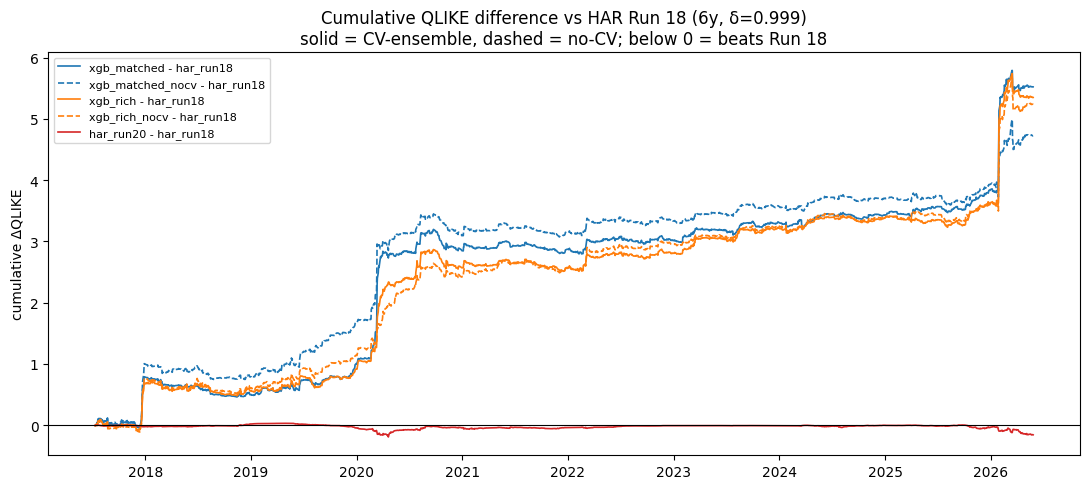

In [9]:
# ===========================================================================
# Cell 8 — Cumulative QLIKE difference vs HAR Run 18 (below 0 = model beats Run 18)
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
for name, color, ls in [("xgb_matched", "C0", "-"), ("xgb_matched_nocv", "C0", "--"),
                        ("xgb_rich", "C1", "-"), ("xgb_rich_nocv", "C1", "--"),
                        ("har_run20", "C3", "-")]:
    ax.plot(losses.index, (losses[name] - losses["har_run18"]).cumsum(),
            label=f"{name} - har_run18", color=color, ls=ls, lw=1.2)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Cumulative QLIKE difference vs HAR Run 18 (6y, δ=0.999)\n"
             "solid = CV-ensemble, dashed = no-CV; below 0 = beats Run 18")
ax.set_ylabel("cumulative ΔQLIKE"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("xgb_vs_har_cum_qlike_6y.png", dpi=150); plt.show()

Mean normalised gain importance (NaN = feature absent from that model):
              xgb_matched  xgb_matched_nocv  xgb_rich  xgb_rich_nocv
log_GVZ          0.406778          0.449603  0.334857       0.343186
x_w              0.328822          0.290171  0.337308       0.343948
x_d              0.138716          0.128226  0.130322       0.113638
macro            0.076259          0.083393  0.064161       0.066524
x_m              0.049424          0.048607  0.057760       0.053507
log_RV_ES             NaN               NaN  0.045136       0.044281
log_RV_crude          NaN               NaN  0.030455       0.034916


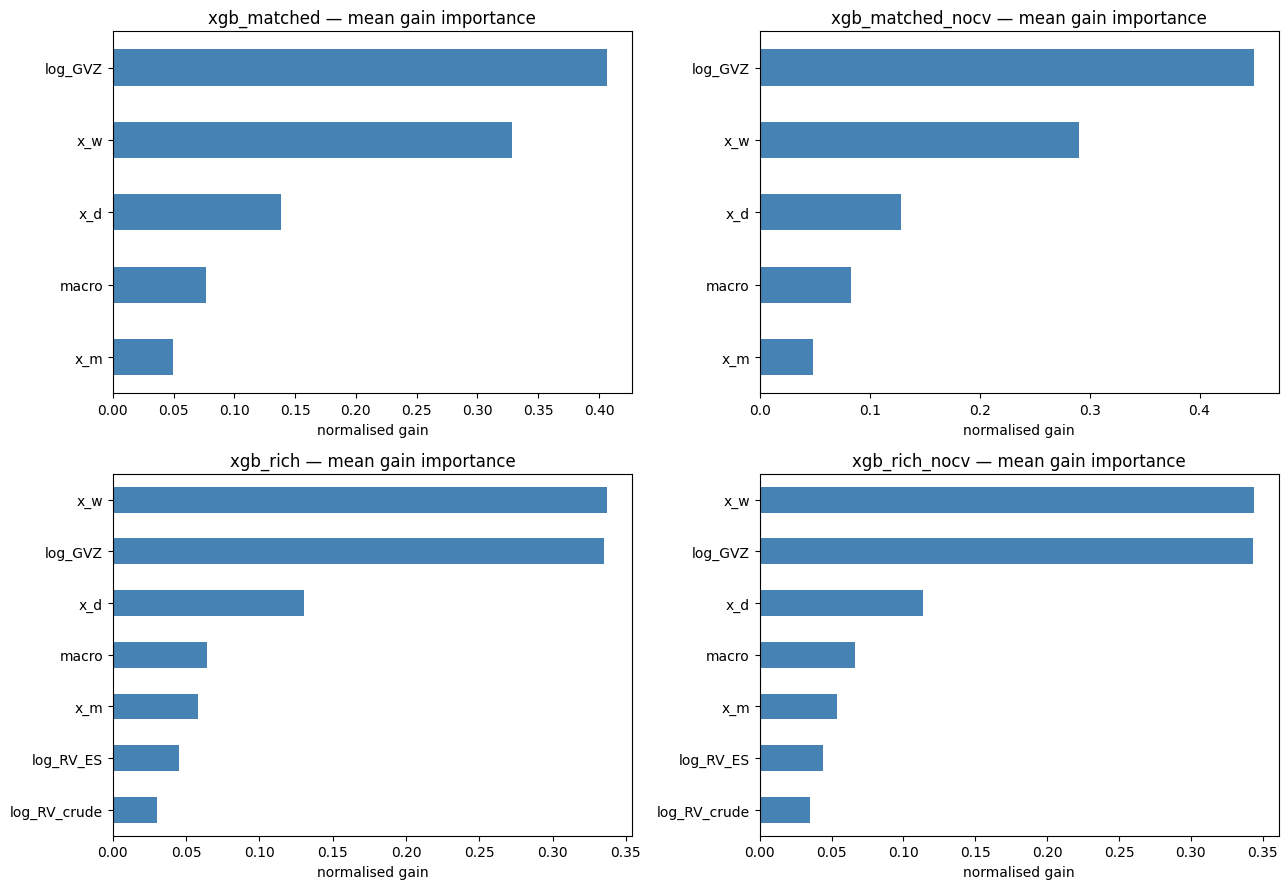

In [10]:
# ===========================================================================
# Cell 9 — Feature importance: CV-ensemble vs no-CV (mean gain across refit boosters)
# ===========================================================================
imp = pd.concat([imp_matched.rename("xgb_matched"),
                 imp_matched_nocv.rename("xgb_matched_nocv"),
                 imp_rich.rename("xgb_rich"),
                 imp_rich_nocv.rename("xgb_rich_nocv")], axis=1)
print("Mean normalised gain importance (NaN = feature absent from that model):")
print(imp.to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [("xgb_matched", imp_matched), ("xgb_matched_nocv", imp_matched_nocv),
          ("xgb_rich", imp_rich), ("xgb_rich_nocv", imp_rich_nocv)]
for ax, (ttl, s) in zip(axes.ravel(), panels):
    s.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{ttl} — mean gain importance"); ax.set_xlabel("normalised gain")
fig.tight_layout(); fig.savefig("xgb_feature_importance_6y.png", dpi=150); plt.show()